In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from torch.optim import AdamW
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from accelerate import init_empty_weights

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.backends.cudnn.benchmark = True

Using device: cuda


In [32]:
file_path = "data/noemoticon_preprocessed.csv"
df = pd.read_csv(file_path)
# df = pd.read_csv(file_path, nrows=100000)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597267 entries, 0 to 1597266
Data columns (total 2 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   polarity  1597267 non-null  int64 
 1   text      1597267 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB
None


In [33]:
label_mapping = {0: 0, 4: 1} #把原始的 0/4 映射成 0/1，实现 二分类任务
df["polarity"] = df["polarity"].map(label_mapping)

In [34]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'].tolist(), df['polarity'].tolist(), test_size=0.3, random_state=42)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=34, stratify=temp_labels)

In [35]:
# Load BERT tokenizer
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [36]:
# Define dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),  # same as flatten()
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [37]:
# Create DataLoader
batch_size = 256
max_length=64
train_dataset = TextDataset(train_texts, train_labels, tokenizer,max_length)
val_dataset = TextDataset(val_texts, val_labels, tokenizer,max_length)
test_dataset = TextDataset(test_texts, test_labels, tokenizer,max_length)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True , num_workers=4, pin_memory=True)
# # val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True )
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [38]:
# Define BERT model
class BertClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(BertClassifier, self).__init__()
        # self.bert = BertModel.from_pretrained("bert-base-uncased") ## >100 hours
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
    
    # def forward(self, input_ids, attention_mask):
    #     outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    #     pooled_output = outputs.pooler_output #DistilBERT  dont have pooler_output
    #     x = self.dropout(pooled_output)
    #     return self.fc(x)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = self.dropout(outputs.last_hidden_state[:, 0, :])
        return self.fc(x)

In [39]:
# Evaluation function
def evaluate(model, val_loader):
    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask)
            preds.extend(outputs.argmax(dim=1).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    # print(classification_report(true_labels, preds))

In [40]:
# Training loop with mixed precision and gradient accumulation
def train(model, train_loader, val_loader, optimizer, criterion, scaler, epochs=3, accumulation_steps=2):
    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        model.train()
        total_loss, total_correct = 0, 0
        optimizer.zero_grad()

        for step, batch in enumerate(tqdm(train_loader)):
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels) / accumulation_steps

            scaler.scale(loss).backward()

            if (step + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_loss += loss.item() * accumulation_steps
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()

        epoch_loss = total_loss / len(train_loader)
        epoch_acc = total_correct / len(train_loader.dataset)
        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)

        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.4f}")
        evaluate(model, val_loader)

    return model, loss_history, acc_history

In [41]:
import time
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

def test(model, test_loader):
    model.eval()
    preds, true_labels = [], []
    batch_times = []

    with torch.no_grad():
        for batch in test_loader:
            start_time = time.time()
            
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            preds.extend(outputs.argmax(dim=1).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

            end_time = time.time()
            batch_times.append(end_time - start_time)

    # 打印分类报告
    print("Classification Report:")
    print(classification_report(true_labels, preds, digits=4))

    # 计算并打印混淆矩阵
    cm = confusion_matrix(true_labels, preds)
    print("Confusion Matrix:")
    print(cm)

    # 可视化混淆矩阵
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    # 可视化每批次处理时间的直方图和正态分布曲线
    batch_times = np.array(batch_times)
    mu, std = batch_times.mean(), batch_times.std()

    plt.figure(figsize=(8, 6))
    sns.histplot(batch_times, bins=30, kde=False, color='blue', stat="density")

    # 绘制正态分布曲线
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2)

    plt.xlabel('Batch Processing Time (seconds)')
    plt.ylabel('Density')
    plt.title(f'Batch Processing Time Distribution\nMean: {mu:.4f} sec, Std: {std:.4f} sec')
    plt.tight_layout()
    plt.show()


100%|██████████| 4368/4368 [09:51<00:00,  7.38it/s]


Epoch 1: Loss = 0.3699, Accuracy = 0.8349


100%|██████████| 4368/4368 [09:54<00:00,  7.35it/s]


Epoch 2: Loss = 0.3257, Accuracy = 0.8588


100%|██████████| 4368/4368 [09:52<00:00,  7.37it/s]


Epoch 3: Loss = 0.3051, Accuracy = 0.8692


100%|██████████| 4368/4368 [09:50<00:00,  7.40it/s]


Epoch 4: Loss = 0.2881, Accuracy = 0.8777


100%|██████████| 4368/4368 [09:50<00:00,  7.40it/s]


Epoch 5: Loss = 0.2720, Accuracy = 0.8857


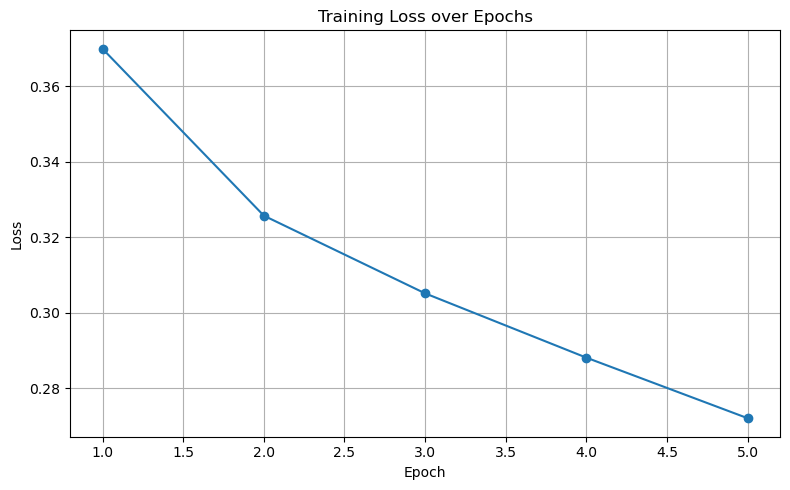

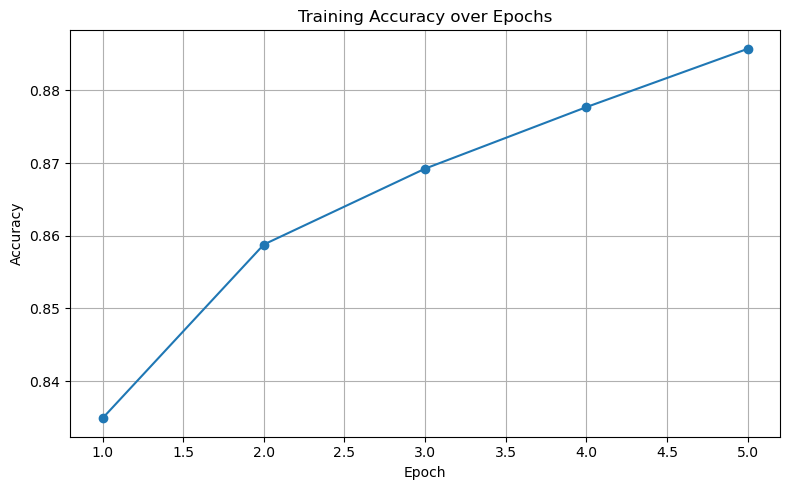

In [42]:
# Start training
# Initialize model
model = BertClassifier().to(device)
# model = torch.compile(BertClassifier().to(device))
optimizer = AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler() # Enable mixed precision

model, loss_history, acc_history = train(
    model, train_loader, val_loader, optimizer, criterion, scaler,
    epochs=5, accumulation_steps=2
)

# Plot after training
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(acc_history)+1), acc_history, marker='o')
plt.title("Training Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0     0.8577    0.8771    0.8673    119536
           1     0.8748    0.8552    0.8649    120055

    accuracy                         0.8661    239591
   macro avg     0.8663    0.8661    0.8661    239591
weighted avg     0.8663    0.8661    0.8661    239591

Confusion Matrix:
[[104848  14688]
 [ 17389 102666]]


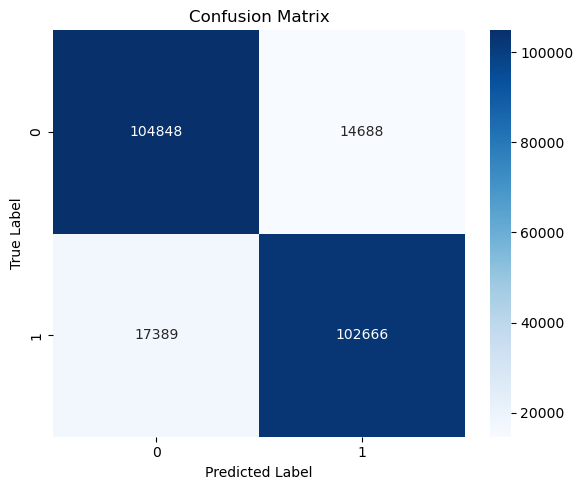

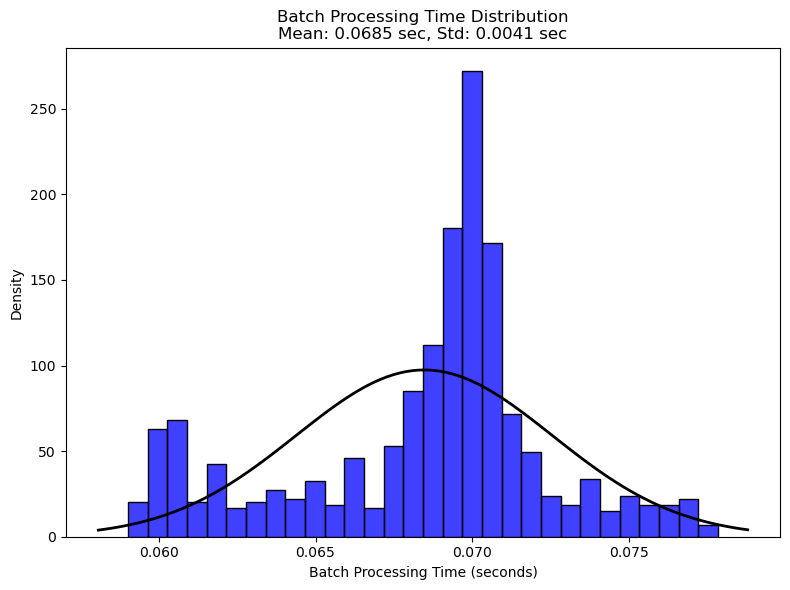

In [43]:
test(model, test_loader=test_loader)